
# BP for Markov-chain diffusion scores: experiments

This notebook accompanies the report and script. It demonstrates the experiment pipeline:

1. Validate grid BP in the Gaussian AR(1) case, where the exact score is available by precision-matrix linear algebra.
2. Estimate grid convergence in the non-Gaussian Laplace-innovation chain.
3. Measure the Gaussian-message approximation error against the reference grid BP score.

The mathematical identity behind everything is

$$
\nabla_{x_i}\log p_t(x)=-\frac{x_i-\alpha_t\,\mathbb E[a_i\mid x]}{\Delta_t}.
$$

Thus every approximation error in the posterior mean translates directly into a score error.


In [1]:

from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display, Markdown

# The notebook lives in the code/ folder. The output folder is ../outputs.
ROOT = Path.cwd().parent if Path.cwd().name == "code" else Path.cwd()
CODE_DIR = ROOT / "code"
OUT_DIR = ROOT / "outputs"
sys.path.insert(0, str(CODE_DIR))

from bp_general_markov_diffusion_experiments import ExperimentConfig, run_all

print("ROOT:", ROOT)
print("OUT_DIR exists:", OUT_DIR.exists())


ROOT: /mnt/data/bp_markov_diffusion_gaussian_approx
OUT_DIR exists: True



## Optional quick rerun

The next cell is commented out by default. Uncomment it to run a small quick version of the experiments from inside the notebook. The report-quality outputs were generated by running the Python script in `report` mode.


In [2]:

# cfg_quick = ExperimentConfig(
#     n=25,
#     validation_grid_sizes=(81, 161),
#     convergence_coarse_grid_size=101,
#     ref_grid_size=201,
#     n_trials=2,
#     output_dir=str(ROOT / "outputs_notebook_quick"),
#     t_values=(0.12, 0.27, 0.60, 1.30),
# )
# run_all(cfg_quick)



## Gaussian grid validation

In the Gaussian AR(1) case, the noisy vector is Gaussian:

$$
\Sigma_t=\alpha_t^2\Sigma_0+\Delta_t I,
$$

and the exact score is

$$
s(x,t)=-\Sigma_t^{-1}x.
$$

This is used to validate the grid BP approximation.


,prior,grid_size,t,rel_score_error_grid_mean,rel_score_error_grid_std,rel_score_error_gauss_projected_mean,rel_score_error_gauss_projected_std,posterior_mean_mse_grid_mean,posterior_mean_mse_gauss_projected_mean
0,gaussian,101.0,0.08,1.374309e-15,2.318306e-16,1.158780e-08,3.067641e-08,4.571915e-31,7.443261e-17
1,gaussian,101.0,0.12,1.031177e-15,1.330413e-16,6.838878e-09,1.279513e-08,3.475844e-31,2.684473e-17
2,gaussian,101.0,0.18,9.556871e-16,2.163394e-16,3.736905e-06,1.026462e-05,3.925980e-31,4.604542e-11
3,gaussian,101.0,0.27,7.413039e-16,1.461309e-16,3.397757e-04,8.978354e-04,2.917863e-31,5.604668e-07
4,gaussian,101.0,0.40,6.467582e-16,1.197108e-16,3.854029e-03,1.159585e-02,3.544834e-31,1.967625e-04
5,gaussian,101.0,0.60,5.128473e-16,9.102328e-17,3.255502e-03,5.455156e-03,2.372845e-31,8.302536e-05
6,gaussian,101.0,0.90,4.401052e-16,7.234759e-17,1.199799e-02,1.115441e-02,3.716385e-31,1.173000e-03
7,gaussian,101.0,1.30,5.546315e-16,4.202863e-16,3.783443e-02,3.392129e-02,4.399208e-30,2.933470e-02
8,gaussian,101.0,1.80,1.084236e-14,1.215627e-14,2.322753e-01,3.646151e-01,7.650865e-27,4.990300e+00
9,gaussian,101.0,2.40,1.733236e-14,3.048509e-14,3.434058e-02,8.342362e-02,1.559706e-25,7.896329e-01


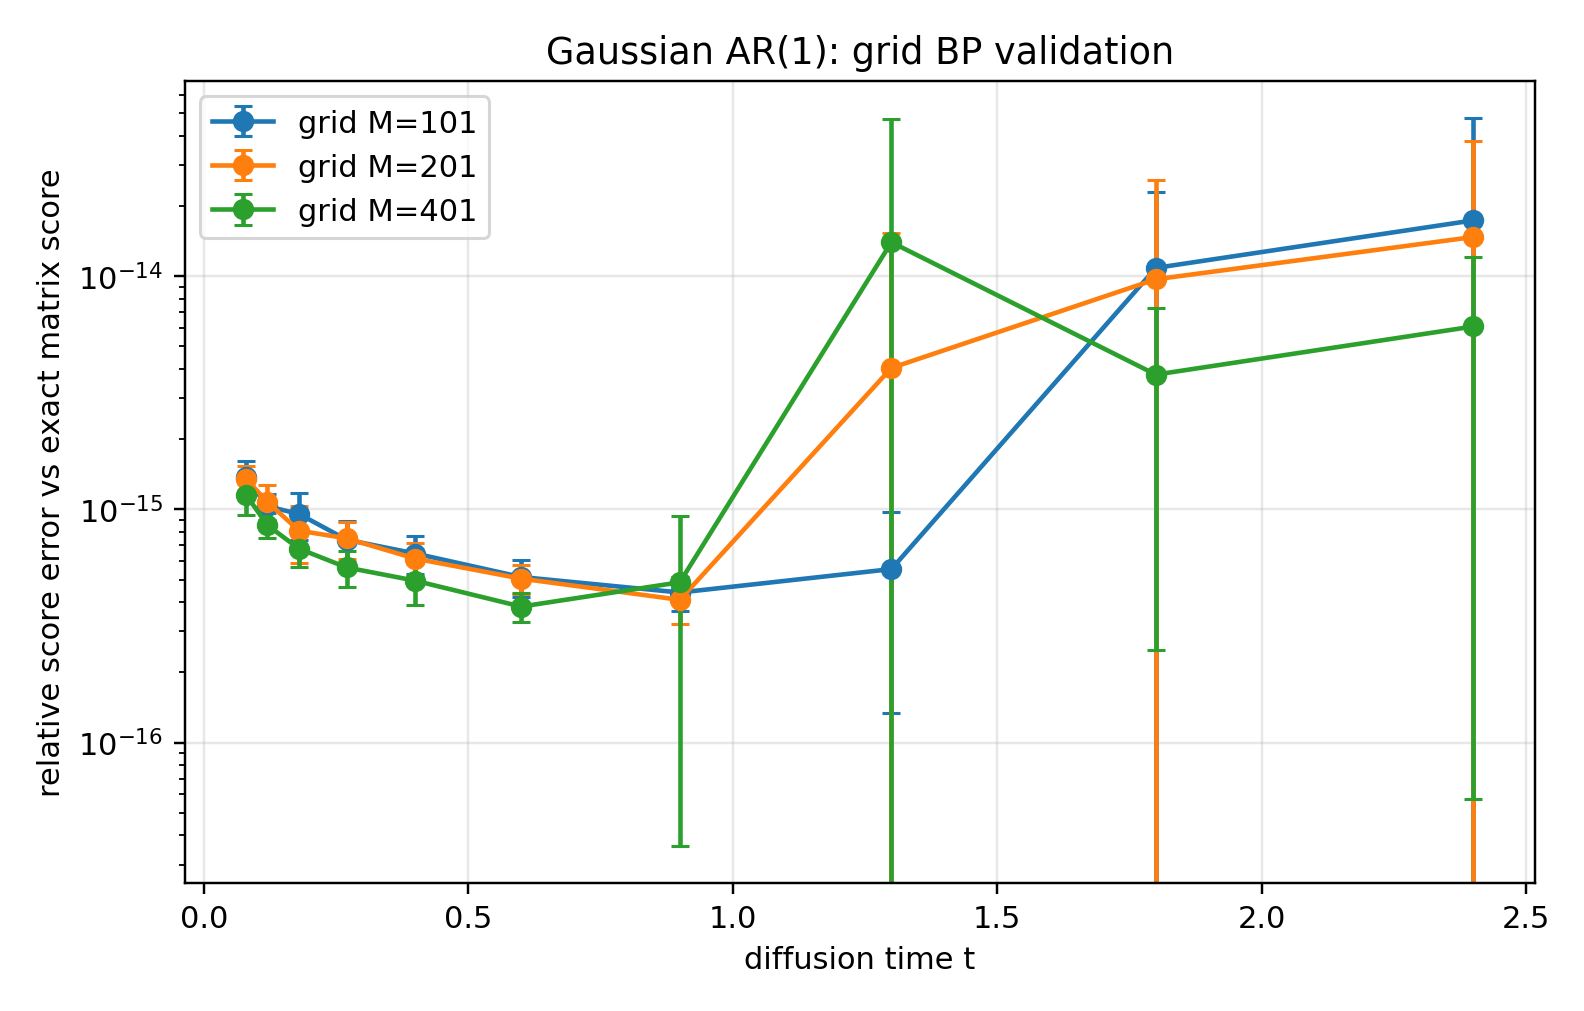

In [3]:

gauss = pd.read_csv(OUT_DIR / "gaussian_grid_validation.csv")
display(gauss.head(12))
display(Image(filename=str(OUT_DIR / "gaussian_grid_validation_rel_error.png")))



## Laplace grid convergence

For the Laplace-innovation chain there is no closed-form precision-matrix score. We therefore compare a coarse grid against a finer grid. This estimates the numerical discretization error of the grid BP reference.


,prior,coarse_grid_size,fine_grid_size,t,relative_score_error_mean,relative_score_error_std,posterior_mean_mse_mean,posterior_mean_mse_std,score_cosine_mean,score_cosine_std
0,laplace,201.0,401.0,0.08,1.067423e-04,3.323794e-05,9.537344e-10,5.666359e-10,1.0,4.330176e-09
1,laplace,201.0,401.0,0.12,6.787049e-05,1.337225e-05,6.580851e-10,1.884129e-10,1.0,1.029088e-09
2,laplace,201.0,401.0,0.18,5.418676e-05,1.229367e-05,7.415442e-10,2.578754e-10,1.0,5.866183e-10
3,laplace,201.0,401.0,0.27,3.325418e-05,8.571518e-06,5.627106e-10,2.843058e-10,1.0,2.915386e-10
4,laplace,201.0,401.0,0.40,2.553846e-05,6.200156e-06,5.772898e-10,1.916026e-10,1.0,1.569148e-10
5,laplace,201.0,401.0,0.60,1.623181e-05,4.374504e-06,5.205408e-10,2.270945e-10,1.0,6.494417e-11
6,laplace,201.0,401.0,0.90,8.877138e-06,2.842637e-06,3.347524e-10,1.600492e-10,1.0,3.012696e-11
7,laplace,201.0,401.0,1.30,3.980006e-06,6.350725e-07,2.016081e-10,6.288623e-11,1.0,2.489286e-12
8,laplace,201.0,401.0,1.80,2.134505e-06,7.094871e-07,1.754352e-10,1.019912e-10,1.0,1.507675e-12
9,laplace,201.0,401.0,2.40,6.864520e-07,2.480766e-07,5.908364e-11,3.596872e-11,1.0,1.612741e-13


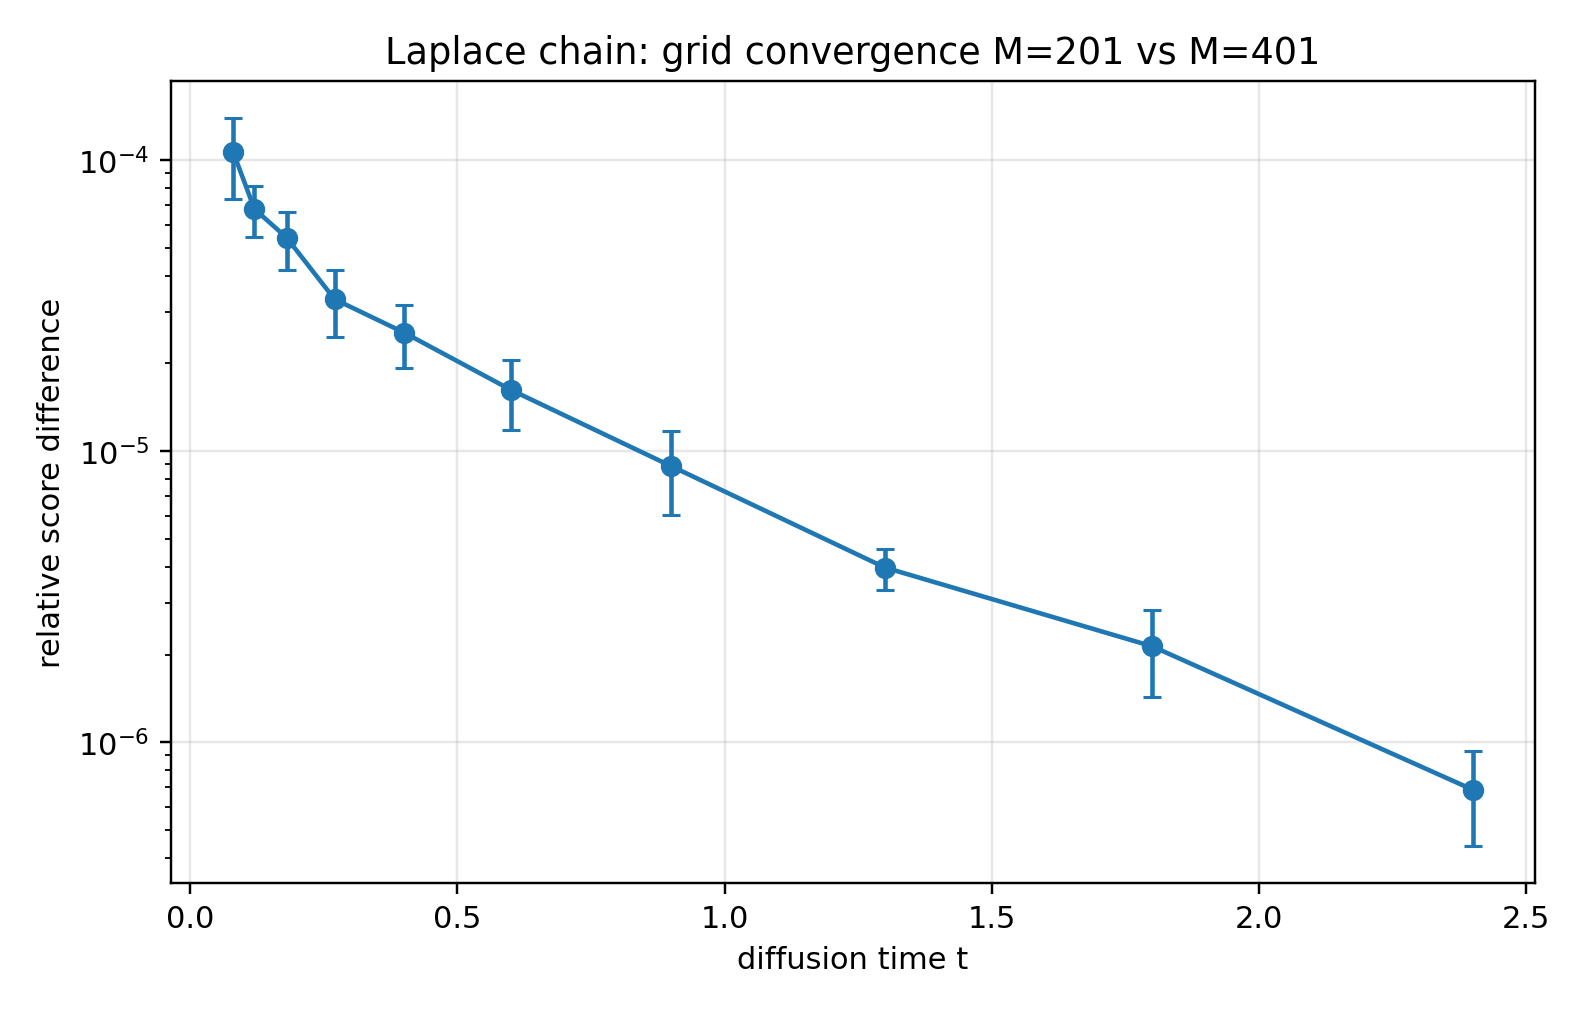

In [4]:

conv = pd.read_csv(OUT_DIR / "laplace_grid_convergence.csv")
display(conv)
display(Image(filename=str(OUT_DIR / "laplace_grid_convergence_rel_error.png")))



## Gaussian-message approximation error in the Laplace chain

The Gaussian-message approximation forces each BP message to be Gaussian and projects the exact outgoing grid message by moment matching. The reference is the grid BP posterior mean on the Laplace chain.


,prior,grid_size,t,alpha,delta,posterior_mean_mse_mean,posterior_mean_mse_std,score_mse_mean,score_mse_std,relative_score_error_mean,relative_score_error_std,score_cosine_mean,score_cosine_std,score_error_identity_rel_residual_mean
0,laplace,401.0,0.08,0.923116,0.147856,0.003258,0.001801,0.126994,0.070204,0.195268,0.046093,0.982070,0.009610,1.248466e-15
1,laplace,401.0,0.12,0.886920,0.213372,0.003918,0.004315,0.067699,0.074553,0.156651,0.077001,0.987324,0.014228,1.275332e-15
2,laplace,401.0,0.18,0.835270,0.302324,0.002308,0.001015,0.017614,0.007750,0.096134,0.020863,0.995555,0.002104,1.447250e-15
3,laplace,401.0,0.27,0.763379,0.417252,0.004665,0.009492,0.015614,0.031773,0.076595,0.062874,0.996129,0.007380,1.942170e-15
4,laplace,401.0,0.40,0.670320,0.550671,0.001980,0.002783,0.002934,0.004124,0.041878,0.024247,0.998952,0.001608,2.994150e-15
5,laplace,401.0,0.60,0.548812,0.698806,0.002801,0.004954,0.001727,0.003056,0.030612,0.019748,0.999427,0.000828,4.373127e-15
6,laplace,401.0,0.90,0.406570,0.834701,0.003873,0.005260,0.000919,0.001248,0.024617,0.017693,0.999566,0.000706,5.617770e-15
7,laplace,401.0,1.30,0.272532,0.925726,2.216251,7.466071,0.192083,0.647085,0.162748,0.412248,0.970424,0.095691,4.283164e-15
8,laplace,401.0,1.80,0.165299,0.972676,0.709925,1.613539,0.020503,0.046600,0.082473,0.113023,0.991902,0.018062,3.902256e-15
9,laplace,401.0,2.40,0.090718,0.991770,0.108393,0.254507,0.000907,0.002129,0.019676,0.021968,0.999589,0.000948,1.115518e-14


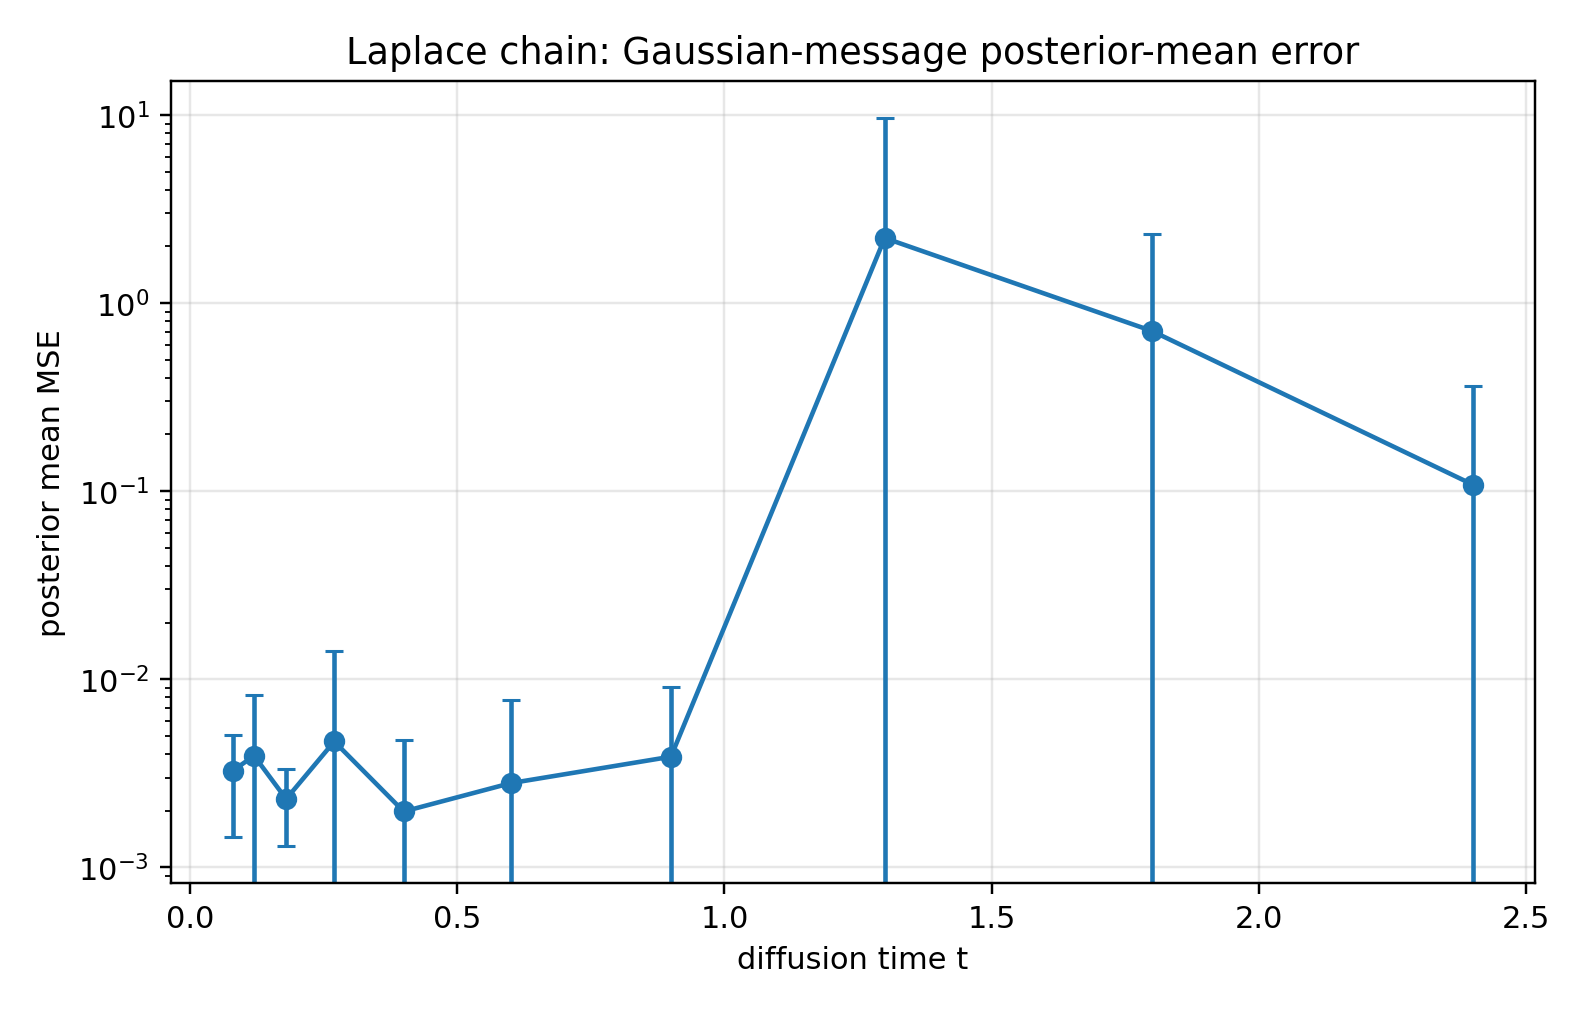

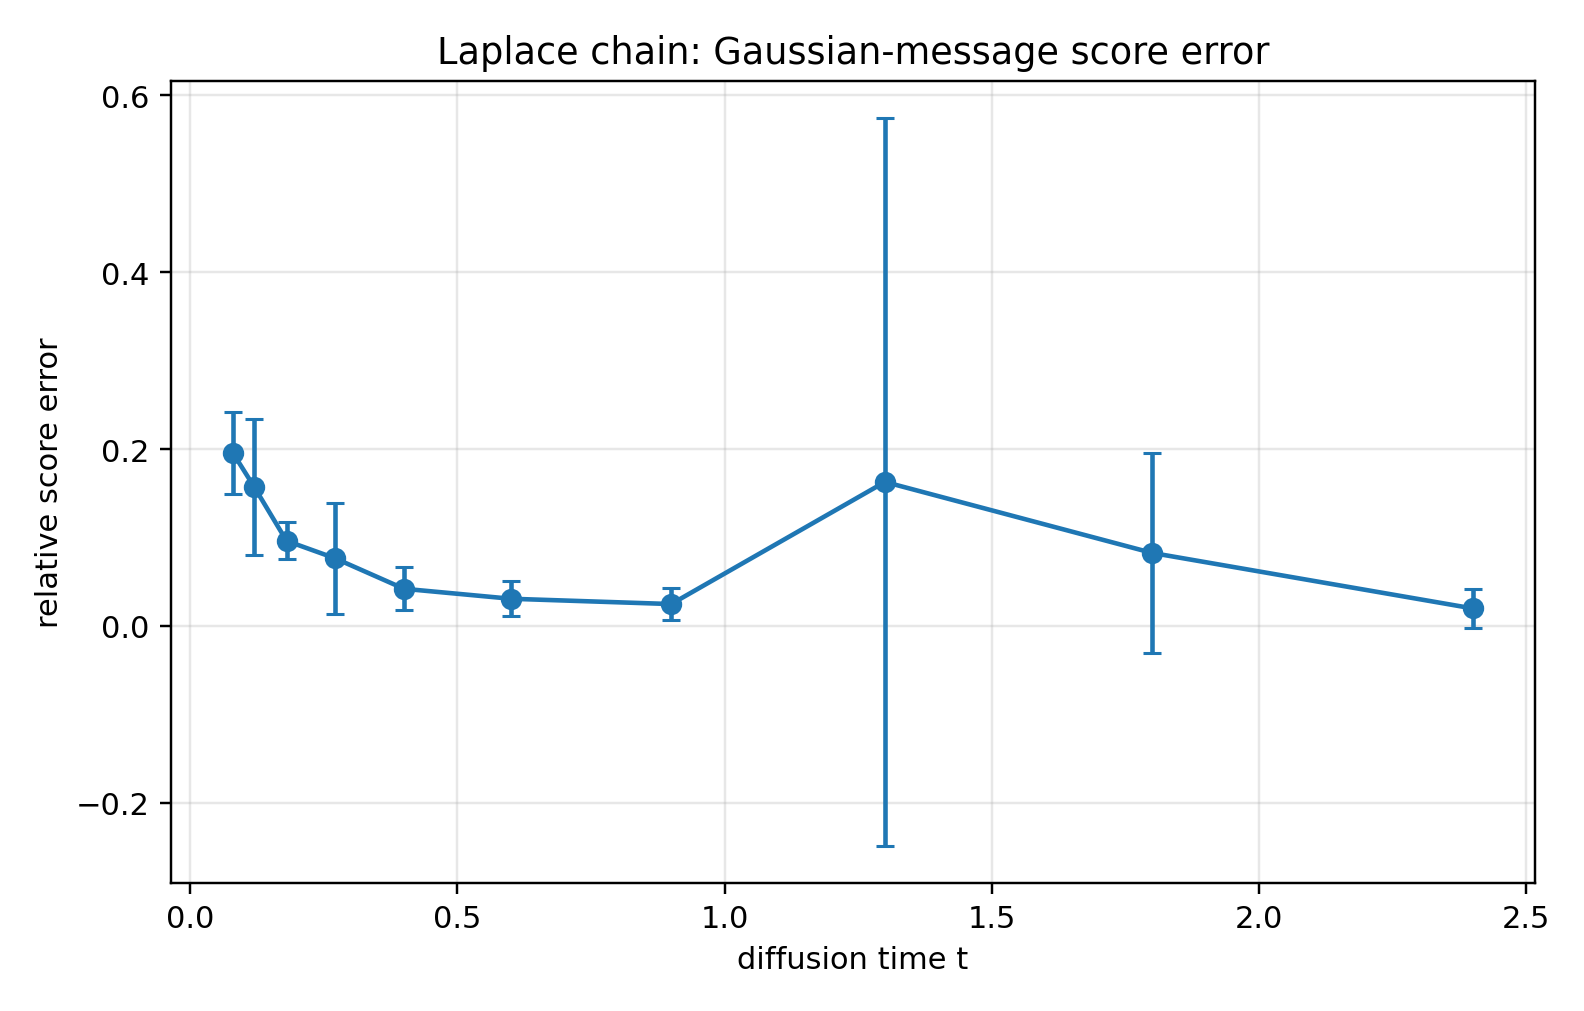

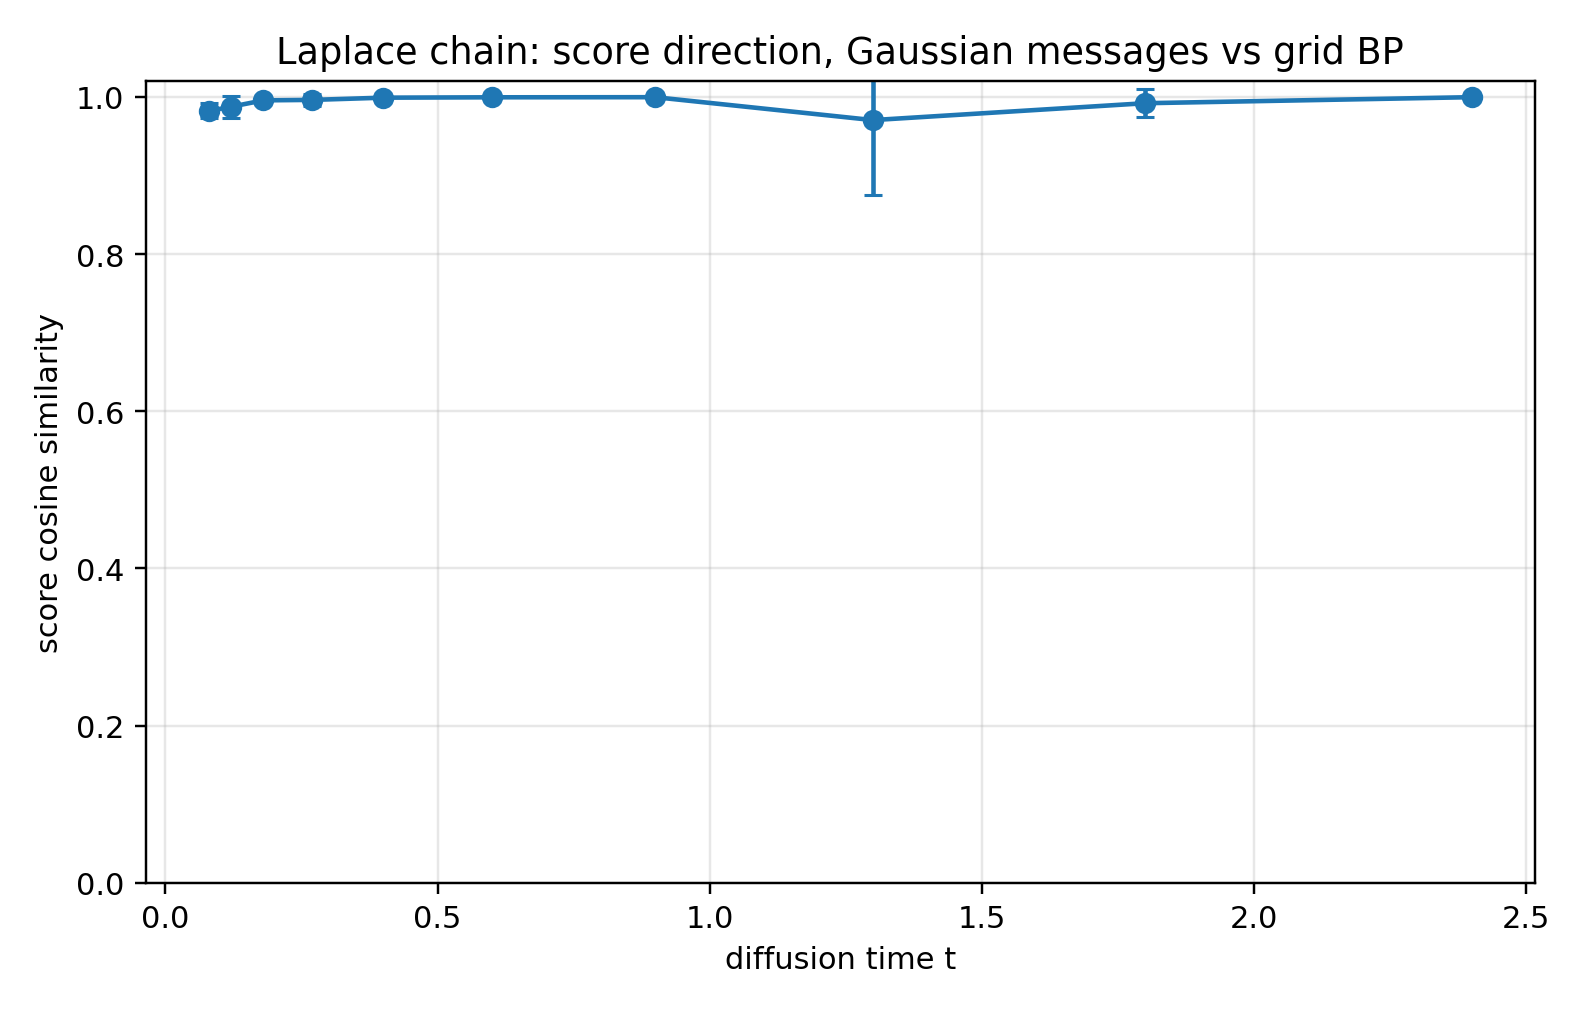

In [5]:

lap = pd.read_csv(OUT_DIR / "laplace_gaussian_message_error.csv")
display(lap)
display(Image(filename=str(OUT_DIR / "laplace_posterior_mean_mse.png")))
display(Image(filename=str(OUT_DIR / "laplace_relative_score_error.png")))
display(Image(filename=str(OUT_DIR / "laplace_score_cosine_similarity.png")))



## Example beliefs

The belief comparison shows a concrete posterior marginal at one site. The grid BP belief is the reference numerical posterior. The Gaussian projected belief is the result of forcing messages to remain Gaussian.


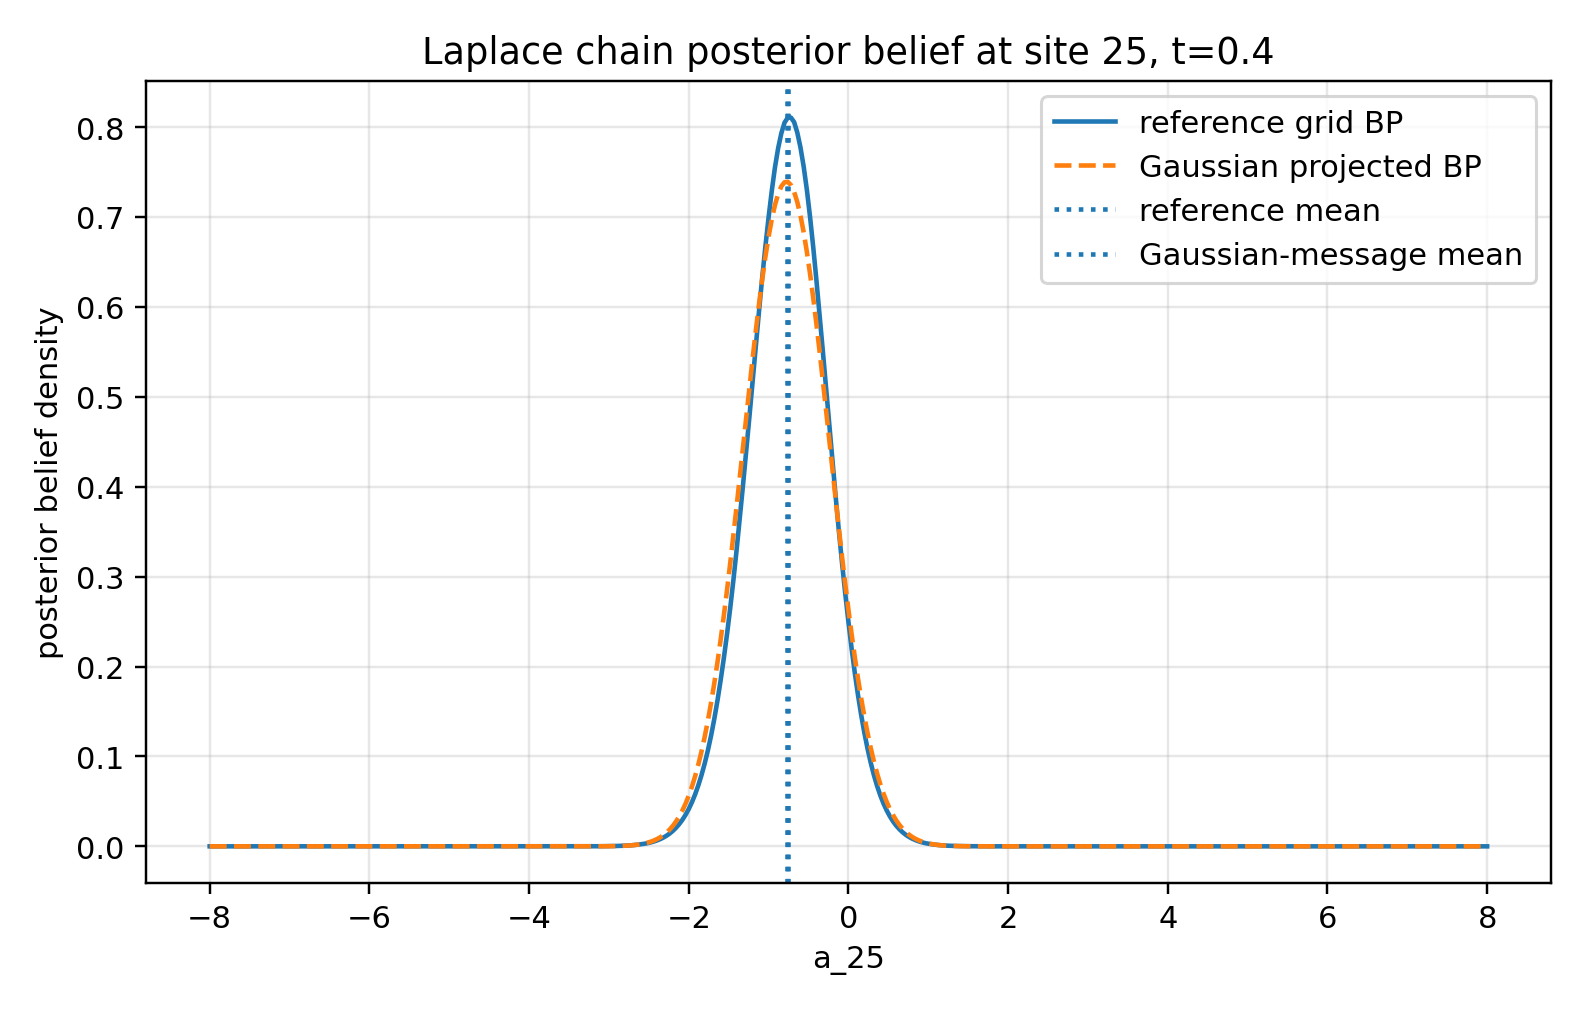

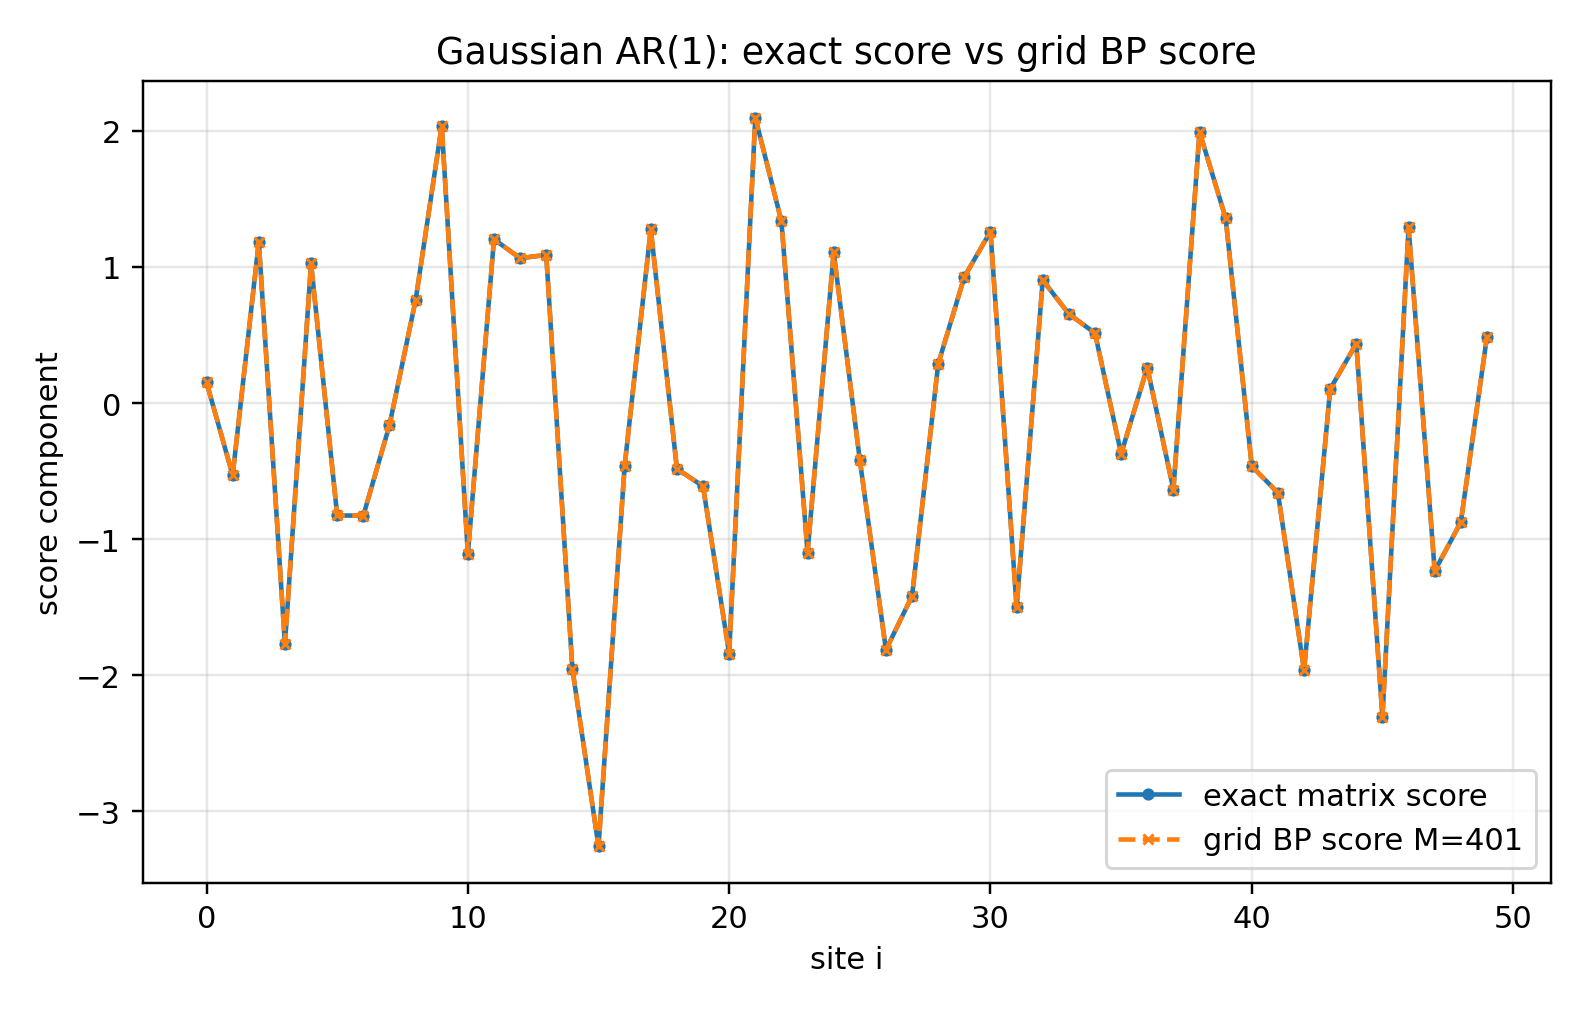

In [6]:

display(Image(filename=str(OUT_DIR / "example_laplace_belief_comparison.png")))
display(Image(filename=str(OUT_DIR / "example_gaussian_grid_vs_matrix_score.png")))



## The diagnostic identity

The script verifies the identity

$$
\widehat s_i-s_i=\frac{\alpha_t}{\Delta_t}(\widehat m_i-m_i).
$$

The CSV column `score_error_identity_rel_residual_mean` should be near machine precision. This confirms that the measured score error is exactly the posterior-mean approximation error, rescaled by the OU factor.


In [7]:

lap[["t", "relative_score_error_mean", "score_cosine_mean", "score_error_identity_rel_residual_mean"]]


,t,relative_score_error_mean,score_cosine_mean,score_error_identity_rel_residual_mean
0,0.08,0.195268,0.982070,1.248466e-15
1,0.12,0.156651,0.987324,1.275332e-15
2,0.18,0.096134,0.995555,1.447250e-15
3,0.27,0.076595,0.996129,1.942170e-15
4,0.40,0.041878,0.998952,2.994150e-15
5,0.60,0.030612,0.999427,4.373127e-15
6,0.90,0.024617,0.999566,5.617770e-15
7,1.30,0.162748,0.970424,4.283164e-15
8,1.80,0.082473,0.991902,3.902256e-15
9,2.40,0.019676,0.999589,1.115518e-14
